# 🛡️ ICS Network Anomaly Detection
## Notebook 01: Real ICS Attack Data Exploration

**Dataset**: ICSSIM - Industrial Control System Simulation Dataset  
**Source**: Kaggle (alirezadehlaghi/icssim)  
**Size**: 125,653 network flows with labeled attacks  

**Objective**: Explore real ICS network traffic data, understand attack patterns, and identify key features for machine learning models.

**Target Applications**: Schneider Electric & Yokogawa OT/ICS Security

In [1]:
# Import libraries
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 1️⃣ Load Real ICS Data

Loading the ICSSIM dataset with 125K+ network flows

In [2]:
# Load the dataset
data_path = Path('../data/raw/kaggle/icssim/Dataset.csv')

print("📂 Loading ICSSIM dataset...")
df = pd.read_csv(data_path, low_memory=False)

print(f"✅ Loaded {len(df):,} network flows")
print(f"   Columns: {len(df.columns)}")
print(f"   Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

df.head()

📂 Loading ICSSIM dataset...


✅ Loaded 45,718 network flows
   Columns: 64
   Memory: 48.70 MB


,sAddress,rAddress,sMACs,rMACs,sIPs,rIPs,protocol,startDate,endDate,start,...,sAckDelayMax,rAckDelayMax,sAckDelayMin,rAckDelayMin,sAckDelayAvg,rAckDelayAvg,IT_B_Label,IT_M_Label,NST_B_Label,NST_M_Label
0,192.168.0.11,192.168.0.21,02:42:c0:a8:00:0b,02:42:c0:a8:00:15,192.168.0.11,192.168.0.21,IPV4-TCP,2022-09-16 11:14:39.510337,2022-09-16 11:14:40.010330,1.663320e+09,...,0.001,0.497,0.0,0.0,0.000219,0.031154,0,Normal,0,Normal
1,192.168.0.12,192.168.0.21,02:42:c0:a8:00:0c,02:42:c0:a8:00:15,192.168.0.12,192.168.0.21,IPV4-TCP,2022-09-16 11:14:39.513421,2022-09-16 11:14:40.013394,1.663320e+09,...,0.000,0.497,0.0,0.0,0.000126,0.027727,0,Normal,0,Normal
2,192.168.0.11,192.168.0.12,02:42:c0:a8:00:0b,02:42:c0:a8:00:0c,192.168.0.11,192.168.0.12,IPV4-TCP,2022-09-16 11:14:39.601160,2022-09-16 11:14:40.054139,1.663320e+09,...,0.198,0.200,0.0,0.0,0.023117,0.030055,0,Normal,0,Normal
3,192.168.0.11,192.168.0.12,02:42:c0:a8:00:0b,02:42:c0:a8:00:0c,192.168.0.11,192.168.0.12,IPV4-TCP,2022-09-16 11:14:40.200719,2022-09-16 11:14:40.602902,1.663320e+09,...,0.197,0.200,0.0,0.0,0.020180,0.028530,0,Normal,0,Normal
4,192.168.0.11,192.168.0.21,02:42:c0:a8:00:0b,02:42:c0:a8:00:15,192.168.0.11,192.168.0.21,IPV4-TCP,2022-09-16 11:14:40.010348,2022-09-16 11:14:40.507654,1.663320e+09,...,0.000,0.493,0.0,0.0,0.000094,0.017102,0,Normal,0,Normal


In [3]:
# Display dataset info
print("\n" + "="*80)
print("DATASET STRUCTURE")
print("="*80)
print(f"\nShape: {df.shape}")
print(f"\nColumn Names:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")


DATASET STRUCTURE

Shape: (45718, 64)

Column Names:
 1. sAddress
 2. rAddress
 3. sMACs
 4. rMACs
 5. sIPs
 6. rIPs
 7. protocol
 8. startDate
 9. endDate
10. start
11. end
12. startOffset
13. endOffset
14. duration
15. sPackets
16. rPackets
17. sBytesSum
18. rBytesSum
19. sBytesMax
20. rBytesMax
21. sBytesMin
22. rBytesMin
23. sBytesAvg
24. rBytesAvg
25. sLoad
26. rLoad
27. sPayloadSum
28. rPayloadSum
29. sPayloadMax
30. rPayloadMax
31. sPayloadMin
32. rPayloadMin
33. sPayloadAvg
34. rPayloadAvg
35. sInterPacketAvg
36. rInterPacketAvg
37. sttl
38. rttl
39. sAckRate
40. rAckRate
41. sUrgRate
42. rUrgRate
43. sFinRate
44. rFinRate
45. sPshRate
46. rPshRate
47. sSynRate
48. rSynRate
49. sRstRate
50. rRstRate
51. sWinTCP
52. rWinTCP
53. sFragmentRate
54. rFragmentRate
55. sAckDelayMax
56. rAckDelayMax
57. sAckDelayMin
58. rAckDelayMin
59. sAckDelayAvg
60. rAckDelayAvg
61. IT_B_Label
62. IT_M_Label
63. NST_B_Label
64. NST_M_Label


## 2️⃣ Understand Attack Labels

The dataset has multiple label columns for different attack taxonomies

In [4]:
# Identify label columns
label_cols = [col for col in df.columns if 'Label' in col or 'label' in col]

print("🎯 Attack Label Columns:")
for col in label_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())
    print(f"Missing values: {df[col].isna().sum()}")

🎯 Attack Label Columns:

IT_B_Label:
IT_B_Label
0    30236
1    15482
Name: count, dtype: int64
Missing values: 0

IT_M_Label:
IT_M_Label
Normal       30236
replay        4300
ddos          4221
port-scan     3235
mitm          3014
ip-scan        712
Name: count, dtype: int64
Missing values: 0

NST_B_Label:
NST_B_Label
0    36706
1     9012
Name: count, dtype: int64
Missing values: 0

NST_M_Label:
NST_M_Label
Normal       36706
mitm          2584
replay        2358
port-scan     1944
ddos          1934
ip-scan        192
Name: count, dtype: int64
Missing values: 0


In [5]:
# Use primary label for analysis
# IT_B_Label appears to be the main binary classification (Normal vs Attack)
primary_label = 'IT_B_Label'

if primary_label in df.columns:
    print(f"\n📊 Primary Label Distribution: {primary_label}")
    label_counts = df[primary_label].value_counts()
    print(label_counts)
    
    # Calculate percentages
    print(f"\nPercentages:")
    for label, count in label_counts.items():
        pct = (count / len(df)) * 100
        print(f"  {label}: {pct:.2f}%")
else:
    print("⚠️  IT_B_Label not found, using IT_M_Label")
    primary_label = 'IT_M_Label'


📊 Primary Label Distribution: IT_B_Label
IT_B_Label
0    30236
1    15482
Name: count, dtype: int64

Percentages:
  0: 66.14%
  1: 33.86%


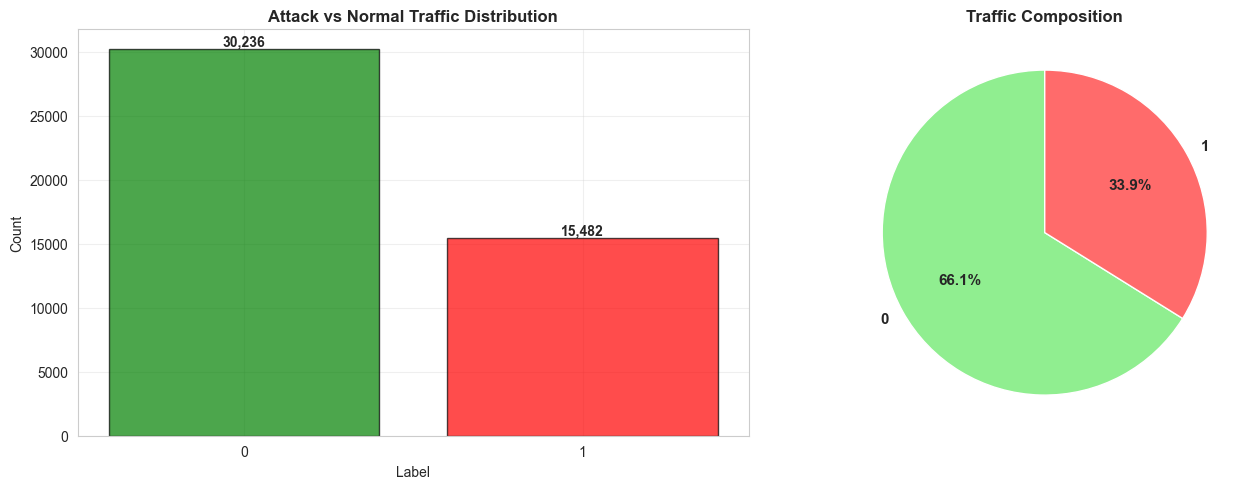

✅ Saved: results/01_label_distribution.png


In [6]:
# Visualize label distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
label_counts = df[primary_label].value_counts()
axes[0].bar(label_counts.index.astype(str), label_counts.values, 
            color=['green', 'red'], edgecolor='black', alpha=0.7)
axes[0].set_title('Attack vs Normal Traffic Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3)

# Add count labels on bars
for i, (label, count) in enumerate(label_counts.items()):
    axes[0].text(i, count, f'{count:,}', ha='center', va='bottom', fontweight='bold')

# Pie chart
colors = ['#90EE90', '#FF6B6B']
axes[1].pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('Traffic Composition', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/01_label_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print("✅ Saved: results/01_label_distribution.png")

## 3️⃣ Network Traffic Analysis

Analyze IP addresses, protocols, and network patterns

In [7]:
# Analyze IP addresses
print("🌐 Network Analysis:")
print(f"\nUnique Source IPs: {df['sIPs'].nunique()}")
print(f"Unique Destination IPs: {df['rIPs'].nunique()}")

print(f"\nTop 10 Source IPs:")
print(df['sIPs'].value_counts().head(10))

print(f"\nTop 10 Destination IPs:")
print(df['rIPs'].value_counts().head(10))

🌐 Network Analysis:

Unique Source IPs: 7
Unique Destination IPs: 6

Top 10 Source IPs:
sIPs
192.168.0.11    29556
192.168.0.12    13425
192.168.0.21      310
192.168.0.1       264
192.168.0.23      207
192.168.0.41      197
192.168.0.22      197
Name: count, dtype: int64

Top 10 Destination IPs:
rIPs
192.168.0.21    24412
192.168.0.12    14016
192.168.0.41     4791
192.168.0.23      730
192.168.0.42      197
224.0.0.251        10
Name: count, dtype: int64



📡 Protocol Distribution:
protocol
IPV4-TCP     43984
ARP           1552
IPV4-ICMP      162
IPV6            10
IPV4-UDP        10
Name: count, dtype: int64


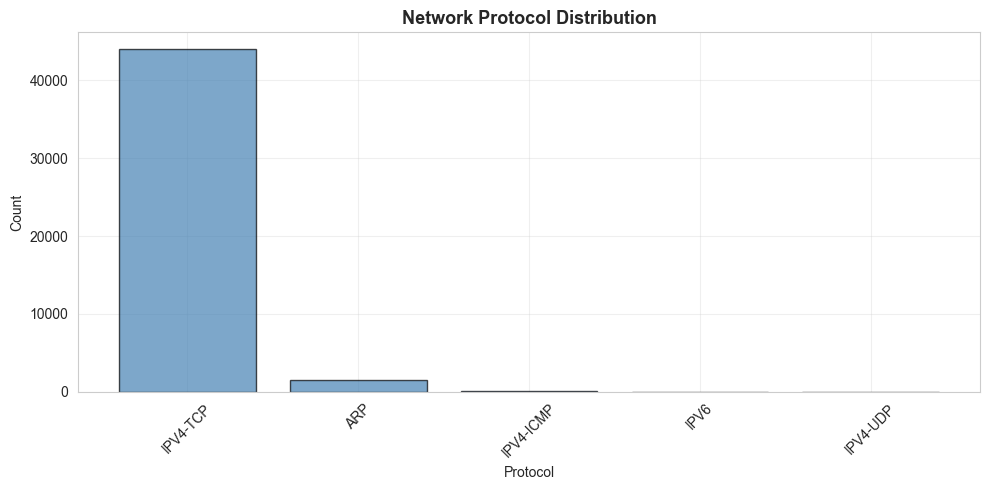

✅ Saved: results/02_protocol_distribution.png


In [8]:
# Protocol distribution
print(f"\n📡 Protocol Distribution:")
print(df['protocol'].value_counts())

# Visualize
plt.figure(figsize=(10, 5))
protocol_counts = df['protocol'].value_counts()
plt.bar(protocol_counts.index, protocol_counts.values, color='steelblue', edgecolor='black', alpha=0.7)
plt.title('Network Protocol Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Protocol')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/02_protocol_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print("✅ Saved: results/02_protocol_distribution.png")

## 4️⃣ Traffic Statistics Analysis

Analyze packet counts, bytes, and timing features

In [9]:
# Key traffic features
traffic_features = ['sPackets', 'rPackets', 'sBytesSum', 'rBytesSum', 'duration']

# Check which features exist
available_features = [f for f in traffic_features if f in df.columns]

print("📊 Traffic Statistics:")
print(df[available_features].describe())

📊 Traffic Statistics:
           sPackets      rPackets      sBytesSum      rBytesSum      duration
count  45718.000000  45718.000000   45718.000000   45718.000000  45718.000000
mean     256.037688    294.323221   12085.275471   14537.262588      0.365488
std     1031.987764   1096.329974   44666.593751   51409.321751      0.184568
min        0.000000      0.000000       0.000000       0.000000      0.000001
25%        7.000000     11.000000     455.000000     680.000000      0.401388
50%       11.000000     15.000000     715.000000     933.000000      0.434423
75%       21.000000     20.000000    1239.000000    1160.000000      0.497859
max     8642.000000   8642.000000  380248.000000  380248.000000      0.500000


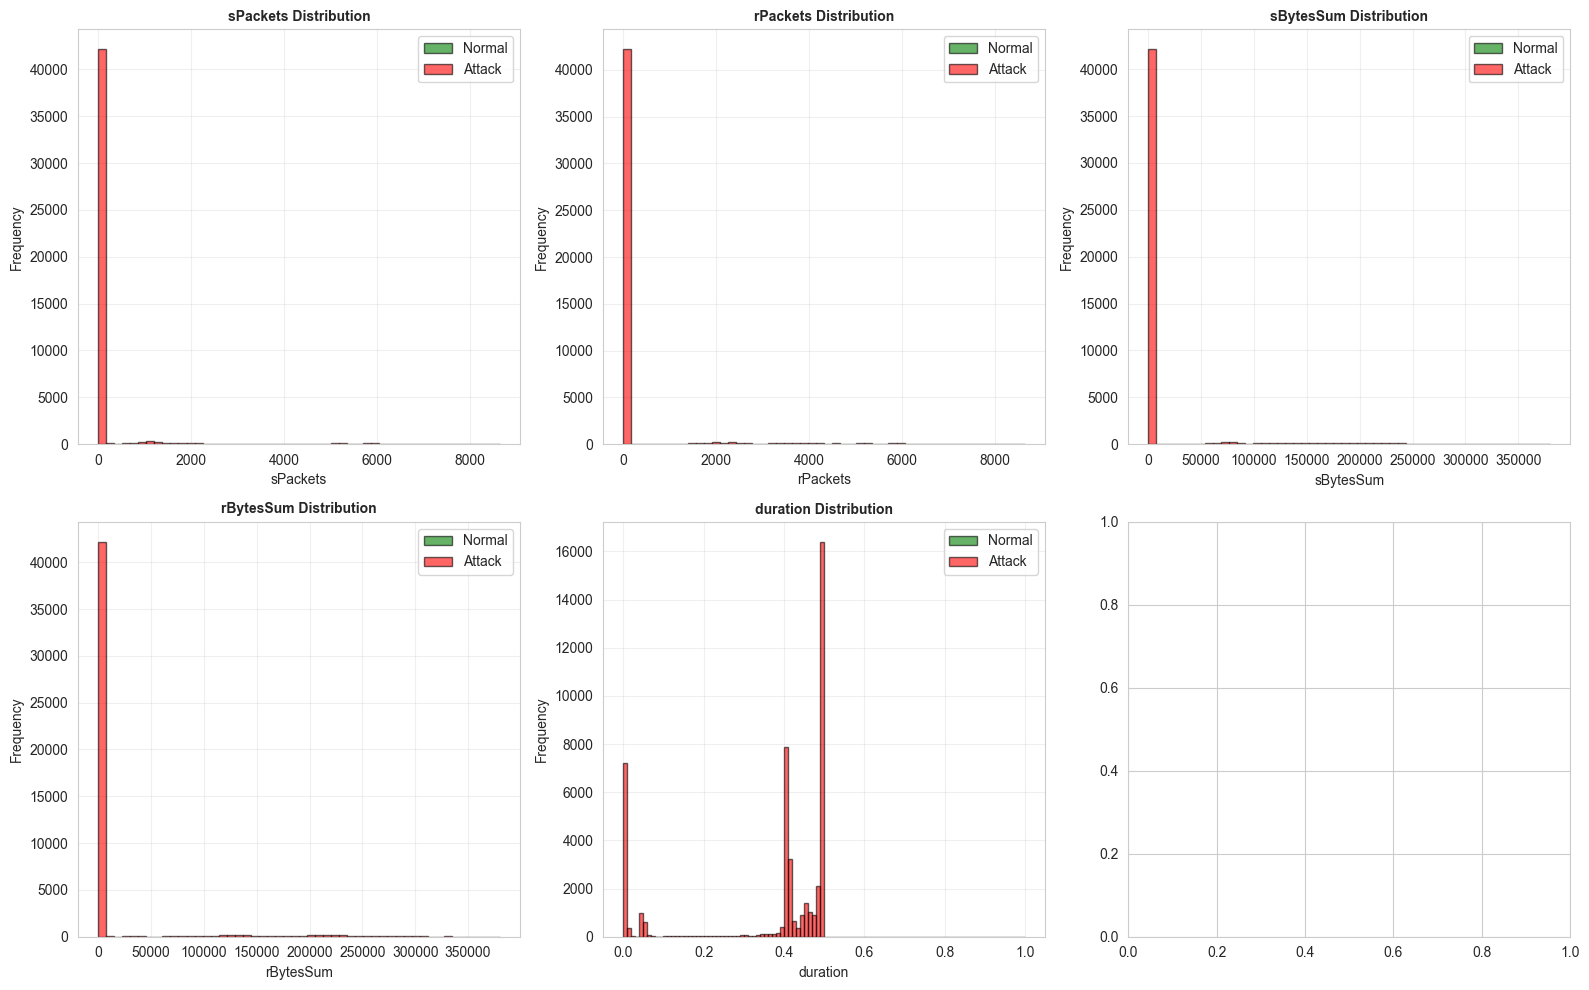

✅ Saved: results/03_traffic_distributions.png


In [10]:
# Visualize traffic distributions for Normal vs Attack
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

features_to_plot = available_features[:6]

for idx, feature in enumerate(features_to_plot):
    if idx < len(axes):
        # Separate normal and attack traffic
        normal_data = df[df[primary_label] == 'Normal'][feature].dropna()
        
        # Handle attack label (could be 'Attack', 1, or other values)
        attack_data = df[df[primary_label] != 'Normal'][feature].dropna()
        
        # Plot histograms
        axes[idx].hist(normal_data, bins=50, alpha=0.6, label='Normal', color='green', edgecolor='black')
        axes[idx].hist(attack_data, bins=50, alpha=0.6, label='Attack', color='red', edgecolor='black')
        
        axes[idx].set_title(f'{feature} Distribution', fontsize=10, fontweight='bold')
        axes[idx].set_xlabel(feature)
        axes[idx].set_ylabel('Frequency')
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/03_traffic_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

print("✅ Saved: results/03_traffic_distributions.png")

## 5️⃣ Attack Pattern Analysis

Compare attack traffic characteristics vs normal traffic

In [11]:
# Compare Normal vs Attack statistics
print("\n" + "="*80)
print("ATTACK vs NORMAL COMPARISON")
print("="*80)

for feature in available_features:
    print(f"\n{feature}:")
    
    normal_stats = df[df[primary_label] == 'Normal'][feature].describe()
    attack_stats = df[df[primary_label] != 'Normal'][feature].describe()
    
    comparison = pd.DataFrame({
        'Normal': normal_stats,
        'Attack': attack_stats,
        'Difference': attack_stats - normal_stats
    })
    
    print(comparison)


ATTACK vs NORMAL COMPARISON

sPackets:
       Normal        Attack  Difference
count     0.0  45718.000000     45718.0
mean      NaN    256.037688         NaN
std       NaN   1031.987764         NaN
min       NaN      0.000000         NaN
25%       NaN      7.000000         NaN
50%       NaN     11.000000         NaN
75%       NaN     21.000000         NaN
max       NaN   8642.000000         NaN

rPackets:
       Normal        Attack  Difference
count     0.0  45718.000000     45718.0
mean      NaN    294.323221         NaN
std       NaN   1096.329974         NaN
min       NaN      0.000000         NaN
25%       NaN     11.000000         NaN
50%       NaN     15.000000         NaN
75%       NaN     20.000000         NaN
max       NaN   8642.000000         NaN

sBytesSum:
       Normal         Attack  Difference
count     0.0   45718.000000     45718.0
mean      NaN   12085.275471         NaN
std       NaN   44666.593751         NaN
min       NaN       0.000000         NaN
25%       Na

## 6️⃣ PLC/SCADA Features Analysis

Analyze industrial control system specific features

In [12]:
# Identify PLC-related columns
plc_cols = [col for col in df.columns if any(keyword in col.lower() 
            for keyword in ['tank', 'valve', 'conveyor', 'bottle', 'level', 'flow'])]

print(f"🏭 Found {len(plc_cols)} PLC/SCADA features:")
for col in plc_cols:
    print(f"  • {col}")

if plc_cols:
    print(f"\nPLC Data Sample:")
    print(df[plc_cols].head(10))
    
    print(f"\nPLC Feature Statistics:")
    print(df[plc_cols].describe())
else:
    print("⚠️  PLC features have many missing values - this is network traffic data")

🏭 Found 0 PLC/SCADA features:
⚠️  PLC features have many missing values - this is network traffic data


## 7️⃣ Missing Value Analysis

🔍 Missing Values Analysis:
         Column  Missing_Count  Missing_Percentage
   rAckDelayMax           3275            7.163480
   rAckDelayMin           3275            7.163480
   rAckDelayAvg           3275            7.163480
sInterPacketAvg           2401            5.251761
   sAckDelayAvg           2268            4.960847
   sAckDelayMin           2268            4.960847
   sAckDelayMax           2268            4.960847
       sFinRate           1858            4.064045
       sSynRate           1858            4.064045
       sPshRate           1858            4.064045
       sAckRate           1858            4.064045
           sttl           1858            4.064045
       sUrgRate           1858            4.064045
       sRstRate           1858            4.064045
        sWinTCP           1858            4.064045
  sFragmentRate           1848            4.042172
       rAckRate           1735            3.795004
           rttl           1735            3.795004
    

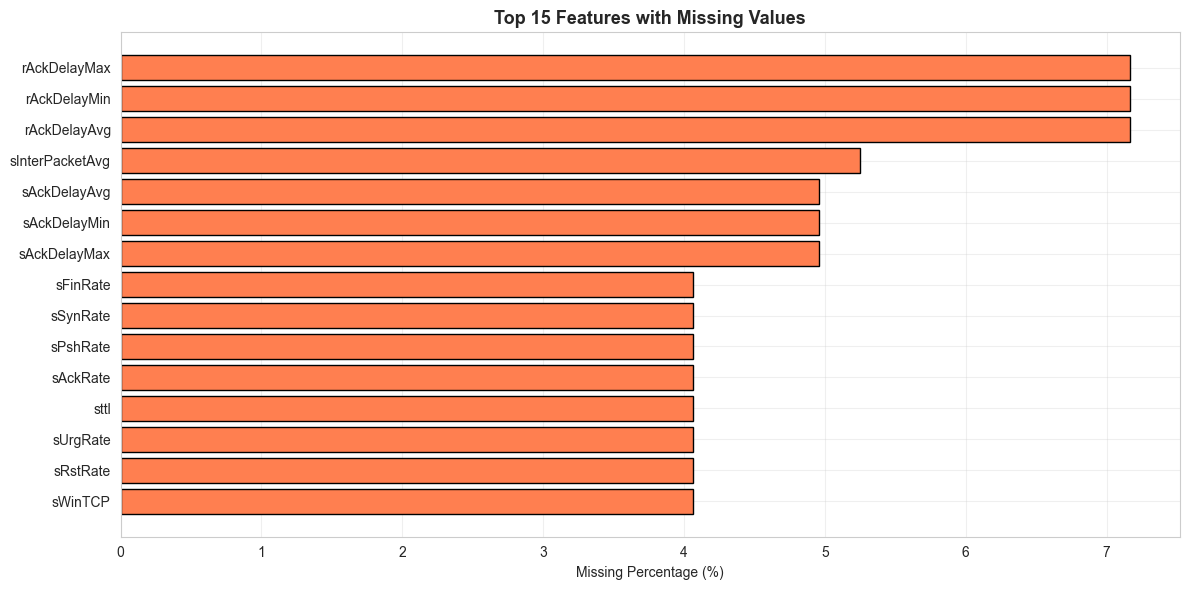

✅ Saved: results/04_missing_values.png


In [13]:
# Calculate missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing_Count': missing.values,
    'Missing_Percentage': missing_pct.values
})

missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

print("🔍 Missing Values Analysis:")
print(missing_df.head(20).to_string(index=False))

# Visualize
if len(missing_df) > 0:
    plt.figure(figsize=(12, 6))
    top_missing = missing_df.head(15)
    plt.barh(range(len(top_missing)), top_missing['Missing_Percentage'].values, color='coral', edgecolor='black')
    plt.yticks(range(len(top_missing)), top_missing['Column'].values)
    plt.xlabel('Missing Percentage (%)')
    plt.title('Top 15 Features with Missing Values', fontsize=13, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('../results/04_missing_values.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    print("✅ Saved: results/04_missing_values.png")

## 8️⃣ Feature Correlation Analysis

📈 Analyzing correlations for 53 numeric features


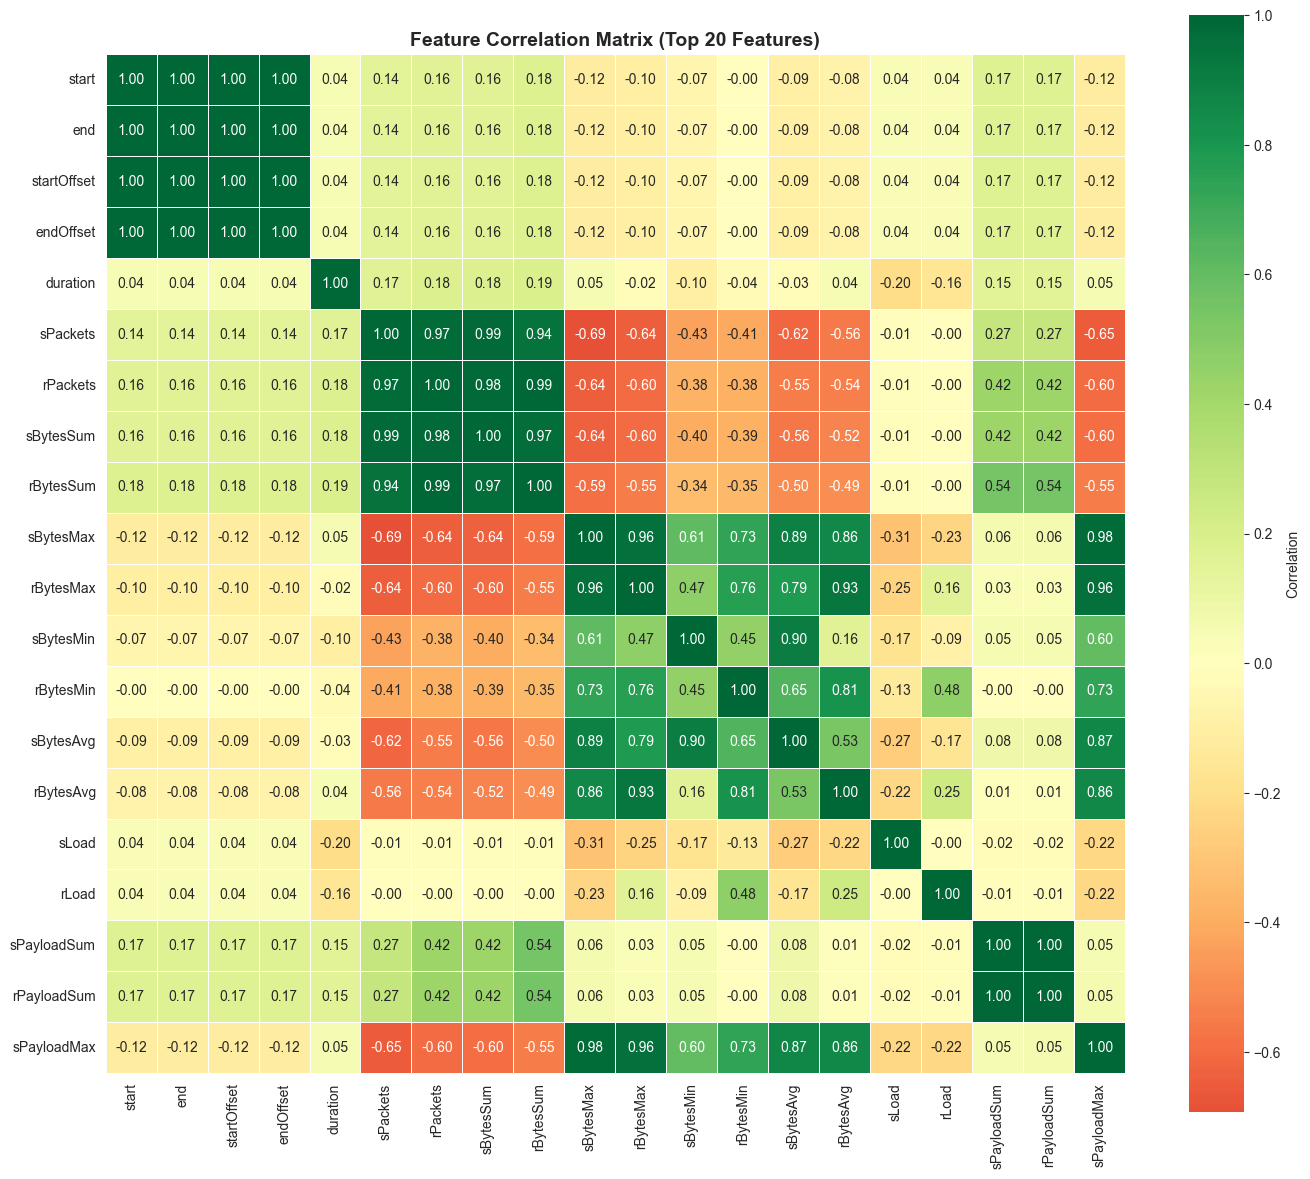

✅ Saved: results/05_correlation_matrix.png


In [14]:
# Select numeric columns for correlation
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Remove columns with too many missing values
numeric_cols = [col for col in numeric_cols if df[col].notna().sum() > len(df) * 0.5]

print(f"📈 Analyzing correlations for {len(numeric_cols)} numeric features")

# Calculate correlation matrix
corr_matrix = df[numeric_cols].corr()

# Plot correlation heatmap (top features)
plt.figure(figsize=(14, 12))
top_features = numeric_cols[:20]  # Top 20 features
sns.heatmap(corr_matrix.loc[top_features, top_features], 
            annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            square=True, linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Feature Correlation Matrix (Top 20 Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/05_correlation_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

print("✅ Saved: results/05_correlation_matrix.png")

## 9️⃣ Key Insights Summary

In [15]:
print("\n" + "="*80)
print("KEY INSIGHTS FROM ICS DATA EXPLORATION")
print("="*80)

insights = []

# Dataset size
insights.append(f"📊 Dataset: {len(df):,} network flows with {len(df.columns)} features")

# Attack distribution
label_counts = df[primary_label].value_counts()
for label, count in label_counts.items():
    pct = (count / len(df)) * 100
    insights.append(f"🎯 {label} traffic: {count:,} ({pct:.1f}%)")

# Network info
insights.append(f"🌐 {df['sIPs'].nunique()} unique source IPs, {df['rIPs'].nunique()} unique destination IPs")

# Protocol info
main_protocol = df['protocol'].value_counts().index[0]
insights.append(f"📡 Primary protocol: {main_protocol}")

# Feature availability
insights.append(f"✅ {len(numeric_cols)} numeric features available for ML")

# PLC features
if plc_cols:
    insights.append(f"🏭 {len(plc_cols)} PLC/SCADA operational features")

# Data quality
complete_features = len([col for col in df.columns if df[col].notna().sum() == len(df)])
insights.append(f"✨ {complete_features} features with no missing values")

for i, insight in enumerate(insights, 1):
    print(f"\n{i}. {insight}")

print("\n" + "="*80)
print("\n✅ Data exploration completed!")
print("➡️  Next: Run notebook 02_feature_engineering.ipynb")
print("="*80)


KEY INSIGHTS FROM ICS DATA EXPLORATION

1. 📊 Dataset: 45,718 network flows with 64 features

2. 🎯 0 traffic: 30,236 (66.1%)

3. 🎯 1 traffic: 15,482 (33.9%)

4. 🌐 7 unique source IPs, 6 unique destination IPs

5. 📡 Primary protocol: IPV4-TCP

6. ✅ 53 numeric features available for ML

7. ✨ 24 features with no missing values


✅ Data exploration completed!
➡️  Next: Run notebook 02_feature_engineering.ipynb


## 🔟 Save Processed Data Summary

In [16]:
# Save dataset summary
summary_data = {
    'total_flows': len(df),
    'total_features': len(df.columns),
    'numeric_features': len(numeric_cols),
    'label_distribution': df[primary_label].value_counts().to_dict(),
    'unique_source_ips': df['sIPs'].nunique(),
    'unique_dest_ips': df['rIPs'].nunique(),
    'protocols': df['protocol'].value_counts().to_dict(),
    'features_with_missing': len(missing_df),
    'plc_features': len(plc_cols)
}

import json
with open('../results/dataset_summary.json', 'w') as f:
    json.dump(summary_data, f, indent=2)

print("✅ Saved: results/dataset_summary.json")

# Save clean feature list for next notebook
good_features = [col for col in numeric_cols if df[col].notna().sum() > len(df) * 0.8]
with open('../results/good_features.txt', 'w') as f:
    f.write('\n'.join(good_features))

print(f"✅ Saved: results/good_features.txt ({len(good_features)} features)")
print("\n🎉 All exploration results saved!")

✅ Saved: results/dataset_summary.json
✅ Saved: results/good_features.txt (53 features)

🎉 All exploration results saved!
